# Práctica - Análisis de Redes Sociales - MDSF
**Author**: Said Daniel Huarita Mollo

Este notebook analiza un grafo de contactos cara a cara entre individuos, simulando interacciones en un período de tiempo y aplicando análisis de centralidad, detección de comunidades y simulación de propagación.

El objetivo es analizar un grafo, que se provee como fichero en el mismo paquete que este enunciado. En este fichero, encontramos solamente dos columnas, correspondiente a una interacción entre dos nodos de la red. Esta red está formada por distintos individuos que tienen contactos cara a cara durante un período de tiempo.

A continuación, dividimos la práctica en apartados, con una breve descripción de que debe contener cada chunk de código donde el alumno desarrollará su respuesta así como las explicaciones que considere oportunas. Por favor, razona todas tus soluciones y escribe las explicaciones en azul.

Junto al título de cada apartado se encuentra la puntuación del mismo (pueden obtenerse hasta 10,5 puntos, aunque solamente se evaluará del 0 al 10).



## Carga de paquetes necesarios

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotnine as p9
import utils as ut

# Análisis de grafos
import networkx as nx
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community import label_propagation_communities
from sklearn.metrics import normalized_mutual_info_score
from networkx.algorithms.community import modularity

## 1. Carga de datos y comprobaciones iniciales (0.5 puntos)

En este apartado, se pide:

* Cargar el fichero adjunto en la práctica.
* Convertirlo en un objeto grafo de networkx. Se cargará como un grafo NO dirigido.
* Comprobar que, efectivamente, tiene el número de nodos y enlaces correcto.
* Simplificar: eliminar bucles y agregar enlaces múltiples, contando cuántas veces aparece un enlace y almacenándolo como un peso de la red resultante.

### 1.1 Cargamos el fichero

In [2]:
data = pd.read_csv('../data/red_contactos.csv',sep=';',header=0)
# Vemos el número de filas y columnas
print('Dimensiones del fichero:', data.shape)
print('Cantidad de nodos:', np.unique(np.array(data).flatten()).shape[0],'\n')
# Vemos las primeras filas
print(data.head())

Dimensiones del fichero: (222744, 2)
Cantidad de nodos: 1390 

  VORIZT1259 VDESZT1259
0    002-002   104-001B
1   104-001B    002-002
2    002-002   104-001B
3   104-001B    002-002
4    002-002    002-002


Antes de armar el grafo reordenamos los nodos para poder contar cuantas interacciones existen.
Ya que el grafo sera no dirigido, no importa el orden en la relación.

In [3]:
data['node1'] = data[['VORIZT1259', 'VDESZT1259']].min(axis=1)
data['node2'] = data[['VORIZT1259', 'VDESZT1259']].max(axis=1)

In [4]:
print('Cantidad de enlaces:',data[['node1', 'node2']].drop_duplicates().shape[0])

Cantidad de enlaces: 54911


### 1.2 Convertimos a un objeto de networkx, como grafo no dirigido.

In [5]:
# Creamos el grafo a partir del DataFrame
g = nx.from_pandas_edgelist(
    data,
    source='VORIZT1259',
    target='VDESZT1259',
    create_using=nx.Graph()
)

# Vemos el número de nodos y enlaces
print('Número de nodos:', g.number_of_nodes())
print('Número de enlaces:', g.number_of_edges())

Número de nodos: 1390
Número de enlaces: 54911


El número de nodos y enlaces es el correcto.

### 1.3 Simplificamos
- Eliminamos bucles. (bucle es un enlace que empieza y acaba en el mismo nodo)
- Agregamos enlaces múltiples, contando cuántas veces aparece un enlace y almacenándolo como un peso de la red resultante.

In [6]:
# Revisamos cuantos bucles hay en el grafo
print('Nodos con bucles:',data[data['node1']==data['node2']]['node1'].nunique())

# Creamos un nuevo DataFrame con el número de interacciones
# entre cada par de nodos como peso del enlace
data_clean = data[['node1', 'node2']].groupby(['node1', 'node2']).size().reset_index(name='weight').copy()

# Eliminamos los bucles (donde node1 == node2)
data_clean = data_clean[data_clean['node1'] != data_clean['node2']]

print('Número de enlaces únicos (sin bucles):', data_clean.shape[0])
print('Peso total de los enlaces:', data_clean['weight'].sum())

Nodos con bucles: 969
Número de enlaces únicos (sin bucles): 53942
Peso total de los enlaces: 183117


In [7]:
# Creamos el grafo a partir del DataFrame limpio
g_simp = nx.from_pandas_edgelist(
    data_clean,
    source='node1',
    target='node2',
    edge_attr='weight',
    create_using=nx.Graph()
)

# Revisamos el número de nodos y aristas
print('Número de nodos:', g_simp.number_of_nodes())
print('Número de enlaces:', g_simp.number_of_edges())
print(f'Suma de pesos (multiplicidad de enlaces): {sum([data["weight"] for u, v, data in g_simp.edges(data=True)])}')

Número de nodos: 1388
Número de enlaces: 53942
Suma de pesos (multiplicidad de enlaces): 183117


## 2. Selección de la componente conexa mayor (0,5 puntos)
En este apartado, se pide realizar los pasos adecuados para generar un nuevo objeto grafo, que sea conexo, y que involucre a todos los nodos y enlaces de la componente conexa mayor del grafo original.

In [8]:
sizes = [len(c) for c in nx.connected_components(g_simp)]
print('Número de componentes conexas:', len(sizes))
print('Tamaños (top 10):', sorted(sizes, reverse=True)[:10])

Número de componentes conexas: 1
Tamaños (top 10): [1388]


Solo hay una componente conexa en el grafo y tiene 1388 nodos, utilizamos esa y construimos un nuevo grafo.

In [9]:
components = nx.connected_components(g_simp)
largest_cc = max(components, key=len)

g_lcc = g_simp.subgraph(largest_cc).copy()
print('Cantidad de nodos en la componente conexa más grande:', g_lcc.number_of_nodes())
print("Cantidad de enlaces en la componente conexa más grande:", g_lcc.number_of_edges())
print(f'Suma de pesos (multiplicidad de enlaces): {sum([data["weight"] for u, v, data in g_lcc.edges(data=True)])}')

Cantidad de nodos en la componente conexa más grande: 1388
Cantidad de enlaces en la componente conexa más grande: 53942
Suma de pesos (multiplicidad de enlaces): 183117


La componente conexa mayor coincide con el grafo completo simplificado, lo que indica que la red es totalmente conexa y no existen subcomponentes aislados.

## 3. Análisis descriptivo de la componente conexa mayor (2.5 puntos)
En este apartado, se pide analizar descriptivamente el grafo usando los conceptos que hemos visto durante las clases de teoría:

* Grado medio (teniendo en cuenta que el grafo tiene pesos)
* Distancia media (teniendo en cuenta que el grafo tiene pesos)
* Diámetro (teniendo en cuenta que el grafo tiene pesos)
* Distribución de grados y ajuste a una Power-Law
* Clustering
* Entropía media de los nodos
* Centralidad de los nodos y comparación con métricas de grado y clustering

Los pesos se deben usar como coste (no como intensidad)


Ya que dependiendo de la función, trata los pesos como costo y en otros casos como fuerza en el enlace, calculamos el peso invertido, para poder utilizarlo cuando sea necesario.

In [10]:
# Calculamos los pesos invertidos (1 / Cost),
# para utilizar en métricas basadas en fuerza de enlaces (similaridad)
for u, v, d in g_lcc.edges(data=True):
    d['inv_weight'] = 1 / d['weight']

### 3.1 Grado medio, Distancia media, Diámetro (Considerando pesos)

In [11]:
# Grado medio (Considerando que el grafo tiene pesos)
degrees_w = dict(g_lcc.degree(weight='weight'))
avg_degree_w = np.mean(list(degrees_w.values()))
print(f'Grado Medio con pesos: {avg_degree_w:.2f}')

# Distancia media considerando pesos
distancia_media_w = nx.average_shortest_path_length(g_lcc, weight='weight')
print(f'Distancia Media con pesos: {distancia_media_w:.2f}')

# Diámetro considerando pesos
diameter_w = nx.diameter(g_lcc, weight='weight')
print(f"Diámetro con pesos: {diameter_w}")

Grado Medio con pesos: 263.86
Distancia Media con pesos: 3.07
Diámetro con pesos: 14


- Grado medio (263.86): Indica que los nodos están muy conectados, con muchas relaciones (o enlaces con peso) en promedio. Esto sugiere una red densa.
- Distancia media (3.07): En promedio, los nodos están a pocos “pasos” (considerando pesos como coste), lo que implica buena conectividad y eficiencia en la red.
- Diámetro moderado (14): El camino más largo entre dos nodos no es excesivo, lo que refuerza que la red está bien conectada y no presenta grandes fragmentaciones.

Conclusión general: La componente conexa mayor es una red densa, bien conectada y relativamente eficiente en términos de distancia entre nodos, lo que sugiere una estructura cohesiva con buena accesibilidad entre sus elementos.

### 3.2 Distribución de grados y ajuste a una Power-Law

In [12]:
# Distribución de Grados y Ajuste a una Power-Law
degrees = dict(g_lcc.degree())
degree_values = np.array(list(degrees.values()))

from powerlaw import Fit
fit = Fit(degree_values, discrete=True)
print(f'Ajuste Power-Law Coeficiente: {fit.power_law.alpha}')
print(f'Ajuste Power-Law xmin: {fit.power_law.xmin}')

# Verificamos la validez del ajuste Power-Law comparándolo con una distribución Log-Normal
R, p = fit.distribution_compare('power_law', 'lognormal')
print('Valor R para la comparación entre Power-Law y Log-Normal:', R)

if R > 0:
    print('La distribución Power-Law es mejor que la Log-Normal')
else:
    print('La distribución Log-Normal es mejor que la Power-Law')

print('p-value para la comparación:', p)


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 244/244 [00:00<00:00, 612.33it/s]

Ajuste Power-Law Coeficiente: 2.9962469319996017
Ajuste Power-Law xmin: 69.0
Valor R para la comparación entre Power-Law y Log-Normal: -48.869729214897404
La distribución Log-Normal es mejor que la Power-Law
p-value para la comparación: 4.605907786238113e-10


- El modelo indica que solo los valores mayores o iguales a 69 siguen una distribución de tipo power law.
- El exponente estimado es aproximadamente α ≈ 2.996, lo que implica una cola pesada moderada.
- Basándonos en los resultados del test de comparación de distribuciones.
    - Se rechaza el modelo Power-law en favor de log-normal.
    - La red no puede ser considerada de libre escala (en sentido estricto).

Graficamos de todas formas para visualizar la diferencia en el ajuste.

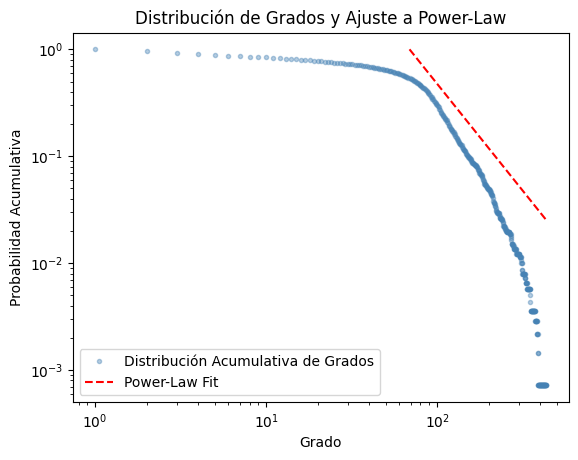

In [13]:
# Calculamos la distribución de grados y su distribución acumulativa
degree_dist = np.bincount(degree_values)[1:]  # Omitimos el grado 0
degree_dist_cumulative = np.cumsum(degree_dist[::-1])[::-1]  # Distribución acumulativa

# Normalizamos la distribución acumulativa
degree_dist_cumulative = degree_dist_cumulative / sum(degree_dist)

# Creamos un rango para los grados
degrees_range = np.arange(1, len(degree_dist_cumulative) + 1)

# Visualizamos la distribución acumulativa de grados
plt.figure()
plt.loglog(degrees_range,
           degree_dist_cumulative, 
           marker='o',
           linestyle='none',
           markersize=3,
           alpha=0.4,
           label='Distribución Acumulativa de Grados', 
           color='steelblue')

# Plot the Power-Law fit, if available
if 'fit' in locals():
    xmin = fit.power_law.xmin
    x_vals = np.arange(xmin, max(degrees_range))
    y_vals = (x_vals / xmin) ** (-fit.power_law.alpha + 1)
    plt.loglog(x_vals, y_vals, color='red', linestyle='--', label='Power-Law Fit')

# Add labels and title
plt.xlabel("Grado")
plt.ylabel("Probabilidad Acumulativa")
plt.title("Distribución de Grados y Ajuste a Power-Law")


plt.legend()
plt.show()

Como se esperaba el ajuste de Power-law no aplica para esta distribución.

### 3.3 Clustering, Entropía media de los nodos

In [14]:
# Coeficiente de Clustering
clustering = nx.transitivity(g_lcc)
print(f'Clustering: {clustering:.4f}')

# Entropía de nodos
# Para cada nodo, calculamos la distribución de la similaridad de sus enlaces
# y luego la entropía de esa distribución
entropy_node = {}

# Recorremos cada nodo en la componente conexa más grande
for node in g_lcc.nodes():
    # Obtenemos los vecinos y la similaridad de los enlaces del nodo
    edges = g_lcc[node]
    similarities = []
    
    # Recorremos cada vecino y obtenemos la similaridad del enlace
    for neighbor, attrs in edges.items():
        similarity = attrs.get('inv_weight')
        similarities.append(similarity)
    

    similarities = np.array(similarities)
    # Calculamos la probabilidad de cada enlace en el nodo
    probs = similarities / similarities.sum()
    # Calculamos la entropía para el nodo
    entropy = -np.sum(probs * np.log2(probs))
    
    # Guardamos la entropía del nodo
    entropy_node[node] = entropy

# Calculamos la entropía promedio de los nodos
avg_node_entropy = np.mean(list(entropy_node.values()))
print(f'Nodos con entropía definida: {len(entropy_node)}')
print(f'Entropía Promedio de los Nodos: {avg_node_entropy:.4f}')


Clustering: 0.2058
Nodos con entropía definida: 1388
Entropía Promedio de los Nodos: 5.2468


- El grafo muestra agrupación moderada (~0.20), indicando grupos de nodos locales.
- La entropia promedio de los nodos (~5.24) indica una alta diversidad en como los nodos distribuyen sus enlaces y pesos. Esto sugiere que,en promedio los nodos distribuyen sus interacciones a traves de varios vecinos de una forma relativamente balanceada.

    Si relacionamos ambos coeficientes la red muestra:
    - Moderada estructura local.
    - Distribución en las interacciones relativamente moderadas.
    - La red es compleja y heterogénea, no es dominada por unos cuantos enlaces altamente influyentes.

### 3.4 Centralidad de los nodos y comparación con métricas de grado y clustering

In [15]:
# Medidas de centralidad por nodo

# Grado por nodo (sin considerar pesos), indica que tan conectado está cada nodo
degree_node = dict(g_lcc.degree())
# Grado por nodo considerando pesos, indica que tan conectado está cada nodo considerando la fuerza de sus enlaces
strength_node = dict(g_lcc.degree(weight='inv_weight'))


# Metricas basadas en distancias (considerando pesos)
# Que tan cercano está cada nodo a los demás (considerando pesos)
closeness_node = nx.closeness_centrality(g_lcc, distance='weight')
# Que tan intermediario es cada nodo considerando pesos
betw_node = nx.betweenness_centrality(g_lcc, weight='weight')

# Metricas basadas en fuerza de enlaces (tomando el peso invertido como similaridad)
# Que tan importante es cada nodo considerando similaridad, basado en la importancia de sus vecinos
eig_node = nx.eigenvector_centrality(g_lcc, weight='inv_weight', max_iter=1000)
# Que tan agrupado está cada nodo considerando similaridad
clust_node =nx.clustering(g_lcc, weight='inv_weight')

“Since edge weights represent costs, they are used directly in shortest-path-based centrality measures, while for clustering they are inverted to reflect connection strength.”

In [16]:
df_comparative = pd.DataFrame({
    'strength': strength_node,
    'degree': degree_node,
    'closeness': closeness_node,
    'betweenness': betw_node,
    'eigenvector': eig_node,
    'clustering': clust_node,
    'entropy': entropy_node
})

df_comparative.describe()

,strength,degree,closeness,betweenness,eigenvector,clustering,entropy
count,1388.000000,1388.000000,1388.000000,1388.000000,1.388000e+03,1388.000000,1388.000000
mean,41.456844,77.726225,0.335682,0.001277,2.036238e-02,0.101577,5.246825
std,34.158206,64.205768,0.049342,0.001929,1.749443e-02,0.091605,1.972545
min,0.166667,1.000000,0.111576,0.000000,2.414217e-07,0.000000,-0.000000
25%,14.479167,25.000000,0.317319,0.000090,5.902957e-03,0.074068,4.424262
50%,38.128553,74.000000,0.346793,0.000599,1.856912e-02,0.091466,5.978759
75%,56.380368,106.000000,0.367807,0.001675,2.872858e-02,0.110216,6.513214
max,217.446079,434.000000,0.436164,0.024017,9.848550e-02,1.000000,8.533709


Revisamos las correlaciones, entre las metricas.

In [17]:
df_comparative.corr(method='pearson')

,strength,degree,closeness,betweenness,eigenvector,clustering,entropy
strength,1.000000,0.993514,0.807793,0.865707,0.986149,-0.119654,0.798220
degree,0.993514,1.000000,0.791509,0.852149,0.977859,-0.127808,0.802353
closeness,0.807793,0.791509,1.000000,0.589688,0.809019,-0.053260,0.920897
betweenness,0.865707,0.852149,0.589688,1.000000,0.823182,-0.100097,0.543088
eigenvector,0.986149,0.977859,0.809019,0.823182,1.000000,-0.093741,0.787447
clustering,-0.119654,-0.127808,-0.053260,-0.100097,-0.093741,1.000000,-0.144047
entropy,0.798220,0.802353,0.920897,0.543088,0.787447,-0.144047,1.000000


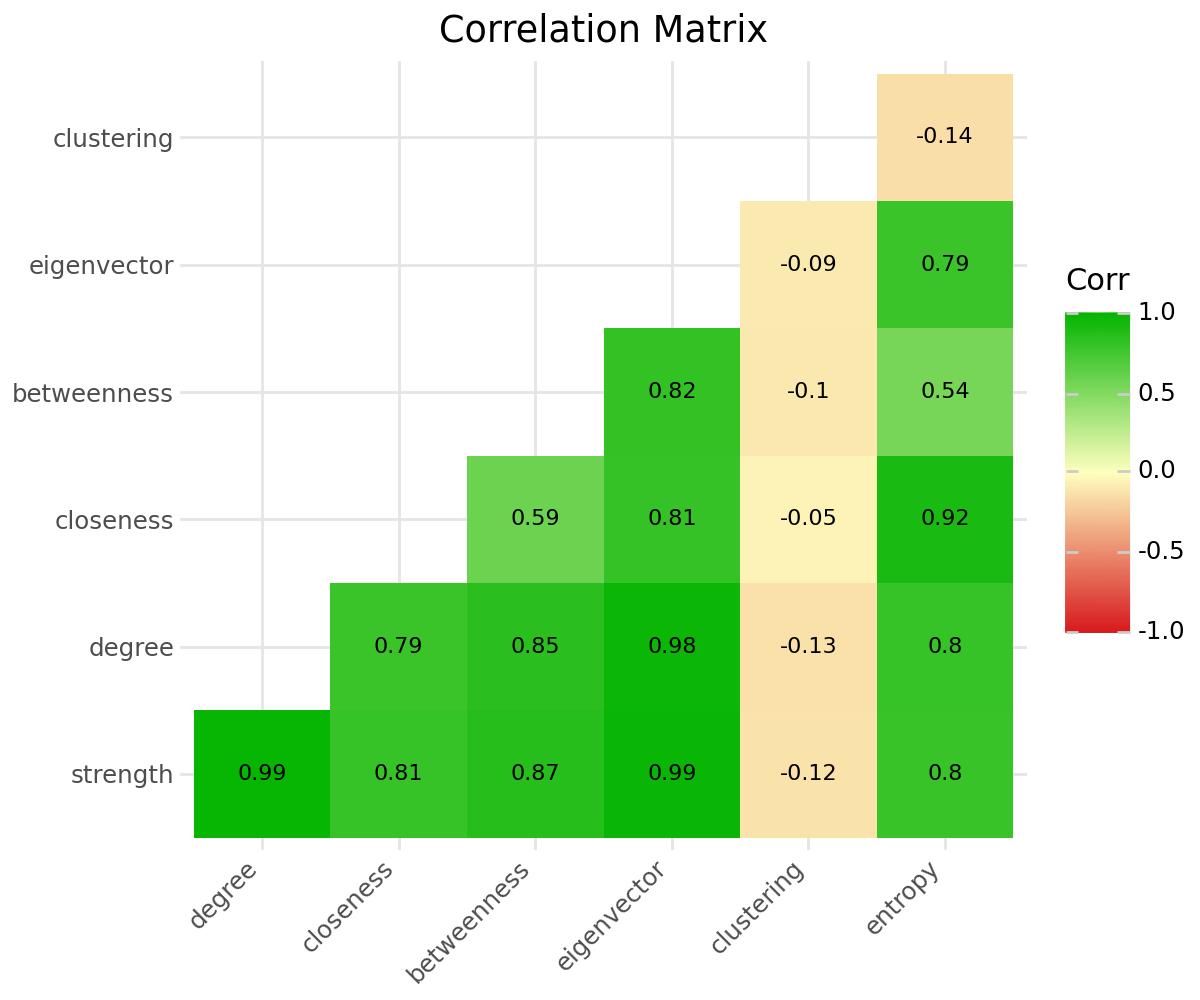

In [18]:
corr_matrix = ut.corr_plot(df_comparative, numeric_var=df_comparative.columns, fig_size=(6, 5))
corr_matrix.show()

- Existe una alta correlación entre degree, strength y eigenvector centrality, lo que indica que los nodos más conectados también tienden a estar conectados con nodos importantes.
- Las métricas de centralidad (degree, closeness, betweenness, eigenvector) están fuertemente correlacionadas entre sí, lo que sugiere que los nodos importantes tienden a ser importantes bajo diferentes criterios.
- Closeness centrality y entropía presentan una correlación muy alta (0.92), indicando que los nodos más cercanos al resto de la red también tienden a tener una mayor diversidad en sus conexiones.
- Betweenness centrality muestra correlaciones moderadas, lo que indica que captura un rol distinto (nodos puente) en comparación con otras métricas de centralidad.
- Clustering presenta correlaciones muy bajas o ligeramente negativas con el resto de métricas, lo que sugiere que la estructura local de los nodos es independiente de su importancia global.

En general, la red muestra una clara distinción entre centralidad (importancia global) y clustering (estructura local).

## 4. Análisis de comunidades de la componente conexa mayor (1.5 puntos)
En este apartado, se pide aplicar dos algoritmos de detección de comunidades sobre la componente conexa mayor, compararlos y seleccionar cuál es, en tu opinión, el que da una mejor respuesta. Razona tu selección.

### 4.1 Método de Louvain

In [19]:
# Detectar comunidades utilizando (Louvain)
communities_louvain = louvain_communities(g_lcc, weight='inv_weight', seed=42)
print('Número de comunidades (Louvain):', len(communities_louvain))
sizes_louvain = sorted([len(c) for c in communities_louvain], reverse=True)
print('Tamaños:', sizes_louvain)

# Modularidad de Louvain 
mod_louvain = modularity(g_lcc, communities_louvain, weight='inv_weight')
print(f'Modularidad comunidades (Louvain): {mod_louvain:.4f}')

Número de comunidades (Louvain): 7
Tamaños: [389, 335, 177, 174, 161, 149, 3]
Modularidad comunidades (Louvain): 0.2137


### 4.2 Método de Label Propagation

In [20]:
# Detectar comunidades utilizando (Label Propagation)
communities_lp = list(label_propagation_communities(g_lcc))
print('Número de comunidades (Label Propagation):', len(communities_lp))
sizes_lp = sorted([len(c) for c in communities_lp], reverse=True)
print('Tamaños:', sizes_lp)

# Modularidad de Label Propagation
mod_lpa = modularity(g_lcc, communities_lp, weight='inv_weight')
print(f'Modularidad comunidades (Label Propagation): {mod_lpa:.4f}')

Número de comunidades (Label Propagation): 4
Tamaños: [1381, 3, 2, 2]
Modularidad comunidades (Label Propagation): 0.0002


### 4.3 Comparación de métodos

In [21]:
# Funcion para convertir las comunidades en etiquetas para cada nodo
def get_labels(nodes, communities):
    label_dict = {}
    # Para cada comunidad, asignamos un número de etiqueta a cada nodo
    for i, comm in enumerate(communities):
        # Para cada nodo en la comunidad, asignamos la etiqueta correspondiente
        for node in comm:
            label_dict[node] = i
    # Aseguramos que las etiquetas estén en el mismo orden que la lista de nodos
    return [label_dict[node] for node in nodes]

# Obtener la lista de nodos de la componente conexa más grande
nodes = list(g_lcc.nodes())

# Transformamos las comunidades en etiquetas para cada nodo
labels_louvain = get_labels(nodes, communities_louvain)
labels_lp = get_labels(nodes, communities_lp)

# Calculamos el NMI entre las dos particiones
nmi_value = normalized_mutual_info_score(labels_louvain, labels_lp)
print(f"NMI Entre Louvain y Label Propagation: {nmi_value:.4f}")

NMI Entre Louvain y Label Propagation: 0.0244


Visualizamos la tabla de contingencia.

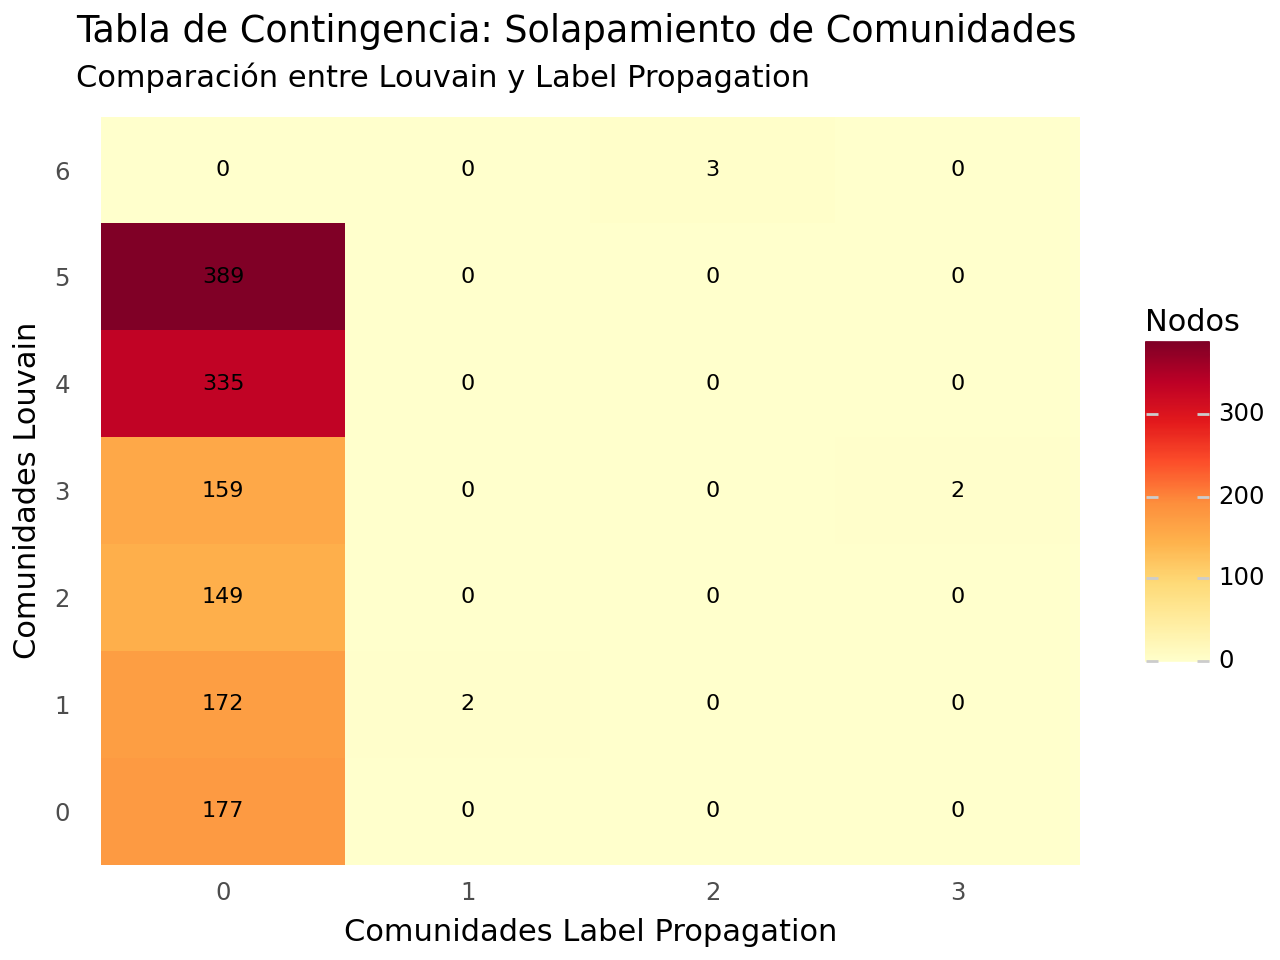

In [22]:
contingency_plot = ut.plot_contingency_table(labels_louvain, 
                                          labels_lp,
                                          method1_name='Louvain',
                                          method2_name='Label Propagation'
                                        )

contingency_plot.show()

Luego de comparar Louvain y Label Propagation, utilizando Normalized Mutual Information (NMI), observamos una baja correlación (0.0244) entre ambos conjuntos de comunidades. Esta discrepancia ocurre debido a que el grafo es muy denso (grado promedio sin pesos ~78), causando que Label Propagation termine en un consenso global con una comunidad predominante.

Asi como también, si comparamos las modularidades (Louvain ~0.21) y (Label Propagation ~0.0002), en Louvain se logran capturar más patrones estructurales, si bien no es un coeficiente alto, esto se debe a que la red es muy densa y es difícil para el algoritmo encontrar comunidades con una fácil claridad.

En vista de lo observado las comunidades seleccionadas serán las que se obtienen con el algoritmo de Louvain, mediante la maximización de modularidad, Louvain identifica exitosamente 7 comunidades diferentes bajo la estructura de costos de la red. Esta segmentación es mucho más eficaz para tareas como clasificación o intervención en comunidades.

## 5. Visualización del grafo por comunidades de la componente conexa mayor (1.5 puntos)
En este apartado, se pide visualizar el grafo coloreando cada nodo en función de la comunidad a la que pertenezca, según tu elección del apartado anterior.


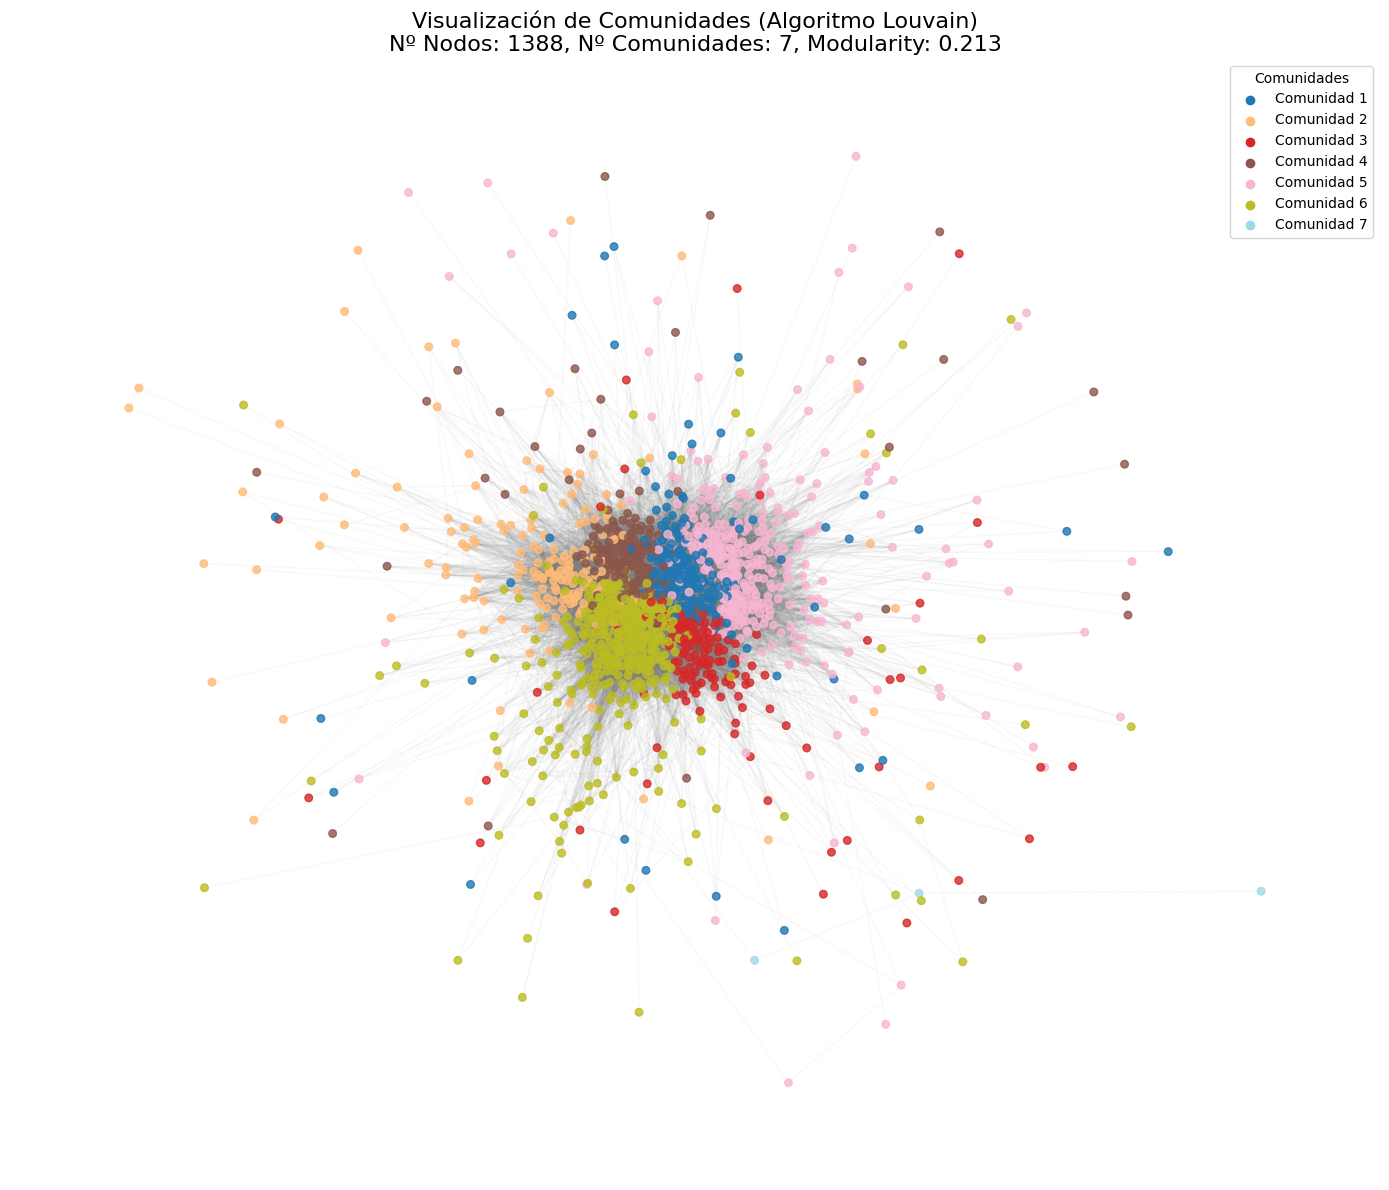

In [23]:
# Preparamos los datos para la visualización de comunidades
# Mapeamos cada nodo a su comunidad {node_id: community_id}
node_to_community = {}
for i, community in enumerate(communities_louvain):
    for node in community:
        node_to_community[node] = i

# Obtenemos la lista de nodos en el mismo orden que g_lcc.nodes() 
# y sus respectivas etiquetas de comunidad
nodes = list(g_lcc.nodes())
community_ids = [node_to_community[node] for node in nodes]
num_communities = len(communities_louvain)

# Elegimos la paleta de colores
cmap = plt.colormaps['tab20'].resampled(num_communities)

# Calculamos el layout del grafo
pos = nx.spring_layout(g_lcc, k=0.15, seed=42, iterations=50) 

# Configuramos el tamaño de la figura para la visualización
plt.figure(figsize=(14, 12))
ax = plt.gca()

# Graficamos los nodos con colores según su comunidad
nx.draw_networkx_nodes(g_lcc, pos, 
                       nodelist=nodes,
                       node_size=30, # Tamaño del nodo
                       node_color=community_ids, # Color del nodo según su comunidad
                       cmap=cmap, # Paleta de colores
                       alpha=0.8
                    )

# Graficamos los enlaces con alta transparencia para evitar el ruido visual
nx.draw_networkx_edges(g_lcc, pos, alpha=0.05, edge_color='gray')

# Titulo
plt.title(f'Visualización de Comunidades (Algoritmo Louvain)\n'
          f'Nº Nodos: {g_lcc.number_of_nodes()}, Nº Comunidades: {num_communities}, Modularity: 0.213', 
          fontsize=16)
plt.axis('off') # Eliminamos los ejes para una visualización más limpia

# Agregamos leyenda
for i in range(num_communities):
    ax.scatter([], [], c=[cmap(i)], label=f'Comunidad {i+1}')

plt.legend(loc='upper right', title="Comunidades", fontsize=10)

plt.tight_layout()
plt.show()

Se observan las comunidades en el gráfico, asi como también lo densa que es, y un efecto similar a una bola de pelos, dada la densidad de los enlaces.

## 6. Difundiendo un rumor (o un virus) en la componente conexa mayor (4 puntos)
Este apartado es el que más peso en la práctica tiene. Vamos a implementar un modelo epidemiológico sobre el grafo que, típicamente, se utiliza para simular escenarios de difusión de enfermedades pero también en contextos como la distribución de rumores e información. Vamos a implementar un modelo SIR que se caracteriza por tener los siguientes parámetros:

* Número de nodos iniciales infectados en el momento t=0 (N).
* Beta: probabilidad de contagio de un nodo infectado (I) a un nodo susceptible de serlo (S)
* Gamma: probabilidad de que un nodo infectado (I) se recupere en momenteo actual (R). Los nodos en estado (R) no son susceptibles y permanecen en este estado infinitamente. Un nodo no puede infectarse y recuperarse en el mismo paso.

Se pide desarrollar una función que tenga como parámetros los tres valores anteriores y un cuarto que sea un grafo que, en nuestro caso, será la componente conexa mayor del grafo original de esta práctica. Dicha función simulará el proceso SIR:

* En t=0, se seleccionan N nodos al azar, que pasarán a estado infectado.
* En t=1, se podrán contagiar con probabilidad Beta nodos que tienen un vecino infectado; OJO: si un nodo en estado S tiene varios vecinos en estado I tiene más probabilidad de infectarse ya que cada vecino tendrá un intento de infectarle.
* Se repite el paso anterior sucesivamente, hasta que no vemos infectados nuevos durante, al menos, 3 iteraciones.

Se pide ejecutar una simulación para tres o cuatro valores del parámetro beta (N y gamma pueden ser fijos en estas simulaciones) de este proceso de manera que se pueda visualizar:

* La curva de nuevos infectados en escala logarítmica para cada caso.
* Las curvas acumuladas para ver el porcentaje total de infectados en cada escenario.
* El grafo que surge de la cascada de contagios: es decir, dos nodos están enlazados ahora si uno ha contagiado al otro. Como es lógico, tanto los nodos como los enlaces de este nuevo grafo son un subconjunto del grafo original.

### 6.1 Definimos las funciones necesarias para la simulación.

Definimos la función para obtener las estadísticas en el periodo t.

In [24]:
def get_info(t_period, graph):
    # Verificamos el estado de los nodos
    status_counts = {'t': t_period, 'susceptible': 0, 'infected': 0, 'recovered': 0}
    for n in graph.nodes():
        status = graph.nodes[n]['status']
        status_counts[status] += 1

    return status_counts

Definimos la función de simulación

In [25]:
def simulate_infection(g_lcc, beta, gamma, n_starter_nodes):
    g_simulation = g_lcc.copy() # Creamos una copia de la conexa mayor para simular la propagación de la infección
    
    # t = 0: Inicializamos la infección en algunos nodos y contamos el número de nodos en cada estado
    # Asignamos el estado 'susceptible' a todos los nodos
    nx.set_node_attributes(g_simulation, 'susceptible',name = 'status')

    # Elegimos n_starter_nodes nodos al azar para iniciar la infección
    initial_infected = np.random.choice(g_lcc.nodes(), size=n_starter_nodes,replace=False)

    # Cambiamos el estado de los nodos seleccionados iniciales a 'infected'
    for n in g_simulation.nodes():
        if n in initial_infected:
            g_simulation.nodes[n]['status'] = 'infected'

    g_infected = nx.Graph() # Creamos un grafo para almacenar los nodos infectados en cada periodo de tiempo
    g_infected.add_nodes_from(initial_infected, t=0) # Agregamos los nodos infectados al grafo de contagiosos

    # Creamos un log para almacenar la información de cada periodo de tiempo
    initial_period_info = get_info(t_period=0, graph=g_simulation)
    initial_period_info['new_infected'] = len(initial_infected)
    initial_period_info['new_recovered'] = 0
    log = [initial_period_info]

    for i in range(1, 30):  # Simulamos 30 periodos como maximo
        new_infected = []

        # Para cada nodo en la red
        for n in g_simulation.nodes():
            # Verificamos si el nodo está infectado
            if g_simulation.nodes[n]['status'] == 'infected':
                # Si el nodo está infectado, intentamos infectar a sus vecinos
                for neighbor in g_simulation.neighbors(n):
                    # Verificamos si el vecino es susceptible
                    if g_simulation.nodes[neighbor]['status'] == 'susceptible':
                        # Intentamos infectar al vecino con probabilidad beta
                        if (np.random.binomial(1, beta) == 1 and 
                            # Evitamos infectar el mismo nodo varias veces en el mismo periodo
                            neighbor not in new_infected):

                            # Agregamos el nodo infectado al grafo de contagiosos con el periodo de tiempo
                            g_infected.add_node(neighbor, t=i)
                            g_infected.add_edge(n, neighbor)
                            new_infected.append(neighbor)

        recovered_nodes = []
        # Para cada nodo en la red
        for n in g_simulation.nodes():
            # Verificamos si el nodo está infectado
            if g_simulation.nodes[n]['status'] == 'infected':
                # Si el nodo está infectado, intentamos recuperarlo con probabilidad gamma
                if np.random.binomial(1, gamma) == 1:  # Con probabilidad gamma, el nodo se recupera
                    recovered_nodes.append(n)

        for n in new_infected:
            g_simulation.nodes[n]["status"] = "infected"

        for n in recovered_nodes:
            g_simulation.nodes[n]["status"] = "recovered"

        t_period_info = get_info(t_period=i, graph=g_simulation)
        t_period_info['new_infected'] = len(set(new_infected))
        t_period_info['new_recovered'] = len(recovered_nodes)

        log.append(t_period_info)

        # Cuando ya llevamos 3 iteraciones o más, revisamos la condición de finalización
        if i >= 2:
            # Revisamos si en los últimos 3 periodos no hubo nuevos infectados ni recuperados
            if (log[-1]['new_infected'] == 0 and
                log[-2]['new_infected'] == 0 and
                log[-3]['new_infected'] == 0):
                #print(f'No hubo cambios en los últimos 3 periodos. Finalizando la simulación en el periodo {i}.')
                break

    return pd.DataFrame(log), g_infected

### 6.2 Simulamos para distintos valores de beta.

In [59]:
gamma = 0.1 # Probabilidad de recuperación
n_starter_nodes = 5 # Número de nodos iniciales infectados

log_simulations = pd.DataFrame([])
g_infected_simulations = []
# Simulamos la propagación de la infección para diferentes valores de beta
# Beta representa la probabilidad de infección
for beta in [0.1, 0.3, 0.5, 0.7]:
    log_simulation,g_infected = simulate_infection(g_lcc, beta, gamma, n_starter_nodes)
    
    log_simulation['beta'] = beta
    log_simulation['gamma'] = gamma
    log_simulation['n_starter_nodes'] = n_starter_nodes
    
    # Agregamos los resultados de esta simulación a los arrays 
    # para almacenarlos y analizarlos posteriormente
    log_simulations = pd.concat([log_simulations, log_simulation], ignore_index=True)
    g_infected_simulations.append(g_infected)

# Calculamos el porcetaje acumulado de infección para cada caso
log_simulations['infected_percentage_acum'] = (log_simulations
                                               .groupby('beta')['new_infected']
                                               .cumsum()
                                               .div(1388)
                                               .mul(100)
                                               .round(2)
                                            )

log_simulations['beta'] = pd.Categorical(log_simulations['beta'])

### 6.3 Curva de nuevos infectados en escala logarítmica, para cada caso.

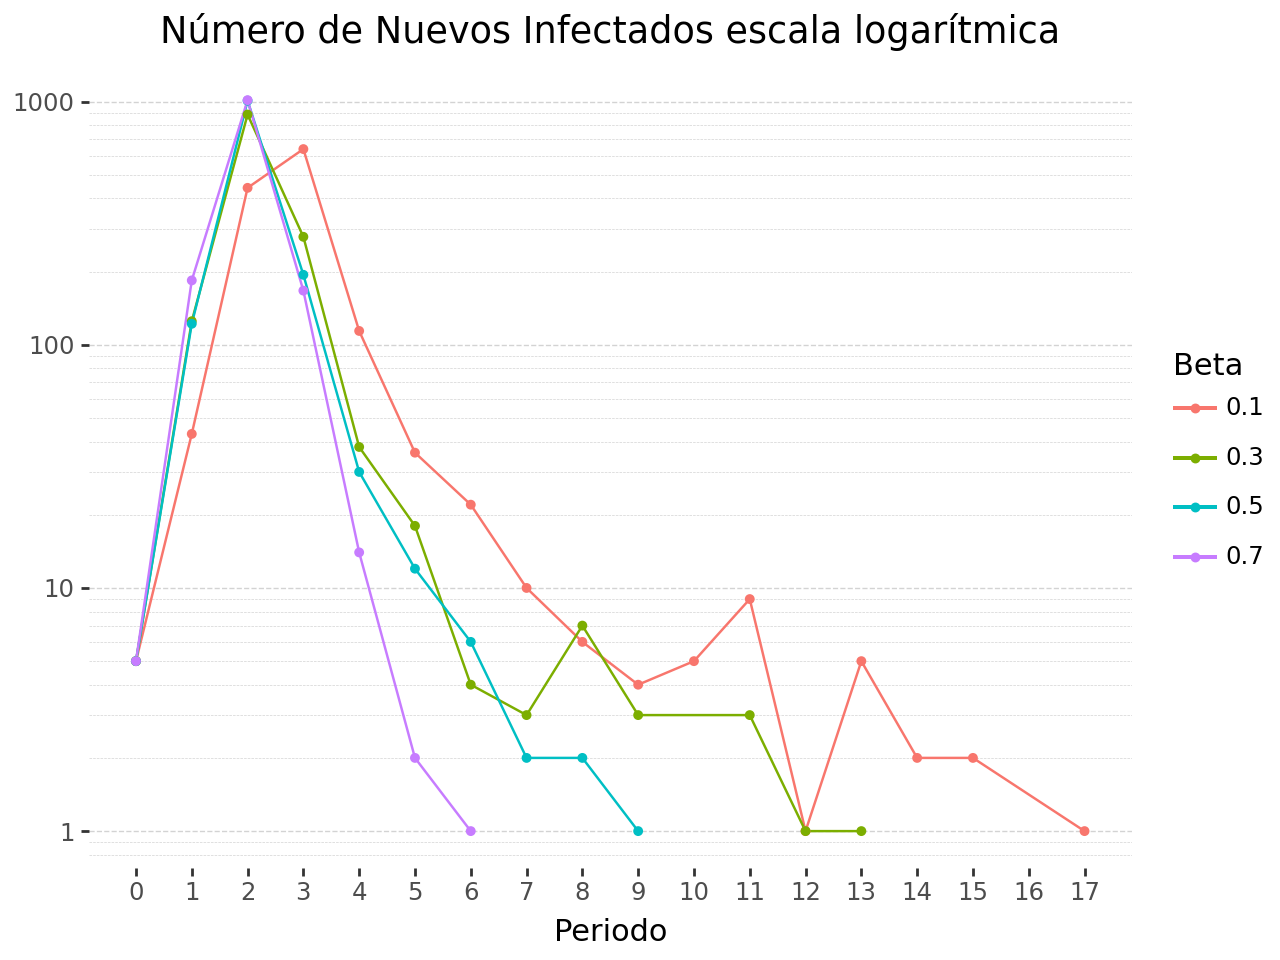

In [81]:
(
    p9.ggplot((log_simulations[log_simulations["new_infected"] > 0]),
              p9.aes(x="t", y="new_infected",color='beta'))
    + p9.geom_line()
    + p9.geom_point(size = 1)
    + p9.scale_y_log10()
    + p9.scale_x_continuous(breaks=range(0, log_simulations["t"].max() + 1))
    + p9.labs(x='Periodo', 
              y='',
              title='Número de Nuevos Infectados escala logarítmica',
              color='Beta')
    + p9.theme(
        panel_background=p9.element_blank(),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
        panel_grid_major_y=p9.element_line(color='lightgray', size=0.5, linetype='dashed'),
        panel_grid_minor_y=p9.element_line(color='lightgray', size=0.25, linetype='dashed'),
    )
    
).show()

### 6.4 Curvas acumuladas para ver el porcentaje total de infectados en cada escenario.

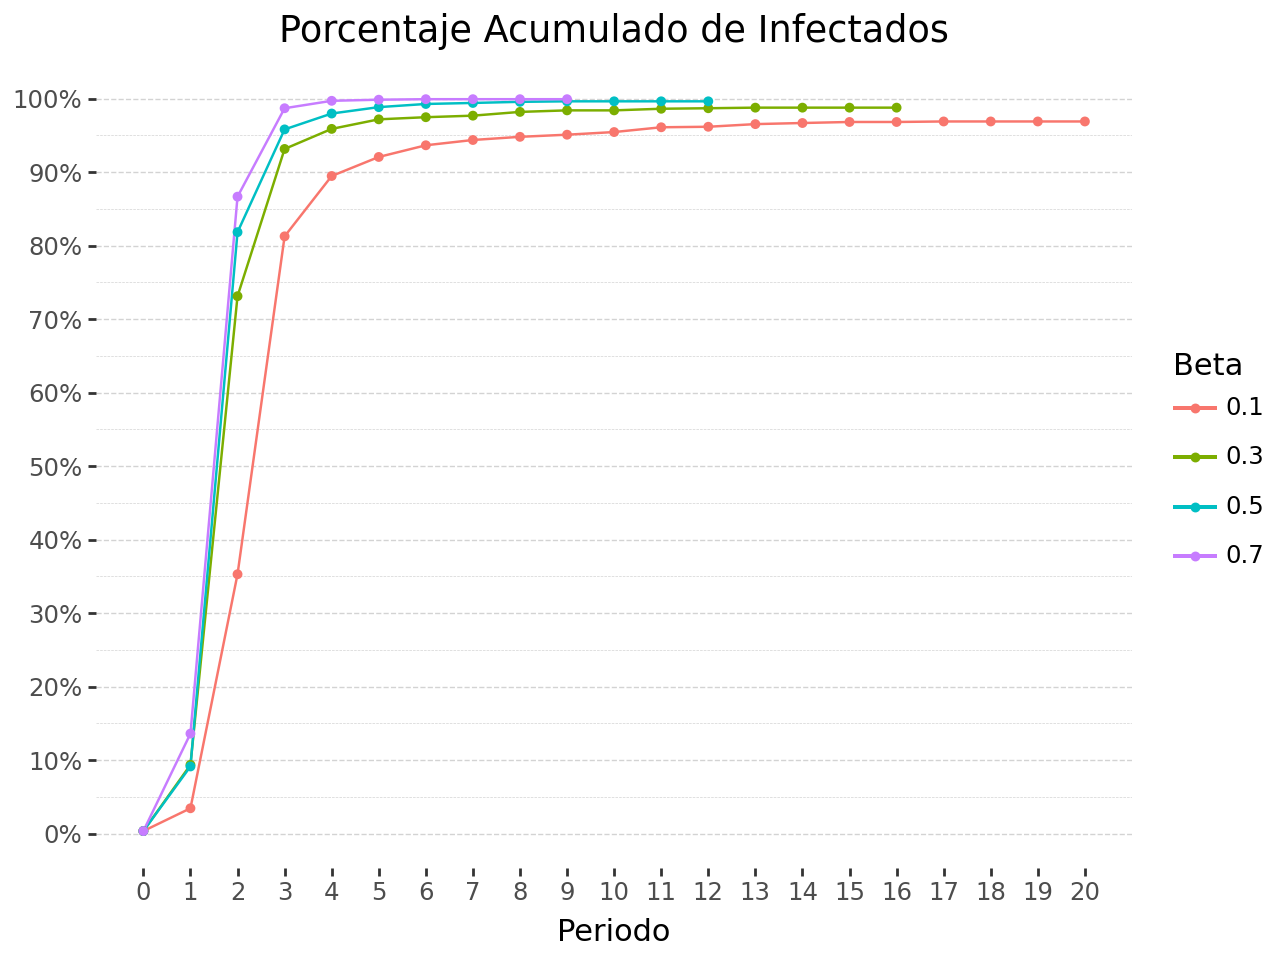

In [84]:
(
    p9.ggplot((log_simulations),
              p9.aes(x='t', y='infected_percentage_acum',color='beta'))
    + p9.geom_line()
    + p9.geom_point(size = 1)
    + p9.scale_x_continuous(breaks=range(0, log_simulations['t'].max() + 1))
    + p9.scale_y_continuous(labels=lambda l: [f'{v:.0f}%' for v in l],breaks=range(0, 101, 10))  # Formateamos el eje y para mostrar porcentajes
    + p9.labs(x='Periodo', 
              y='',
              title='Porcentaje Acumulado de Infectados',
              color='Beta')
    + p9.theme(
        panel_background=p9.element_blank(),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
        panel_grid_major_y=p9.element_line(color='lightgray', size=0.5, linetype='dashed'),
        panel_grid_minor_y=p9.element_line(color='lightgray', size=0.25, linetype='dashed'),
    )
    
).show()

### 6.5 Grafo que surge de la cascada de contagios.

#### 6.5.1 Beta = 0.1

In [142]:
log_simulations[log_simulations['beta'] == 0.1]

,t,susceptible,infected,recovered,new_infected,new_recovered,beta,gamma,n_starter_nodes,infected_percentage_acum
0,0,1383,5,0,5,0,0.1,0.1,5,0.36
1,1,1340,47,1,43,1,0.1,0.1,5,3.46
2,2,898,484,6,442,5,0.1,0.1,5,35.30
3,3,260,1078,50,638,44,0.1,0.1,5,81.27
4,4,146,1083,159,114,109,0.1,0.1,5,89.48
5,5,110,1017,261,36,102,0.1,0.1,5,92.07
6,6,88,929,371,22,110,0.1,0.1,5,93.66
7,7,78,848,462,10,91,0.1,0.1,5,94.38
8,8,72,779,537,6,75,0.1,0.1,5,94.81
9,9,68,718,602,4,65,0.1,0.1,5,95.10


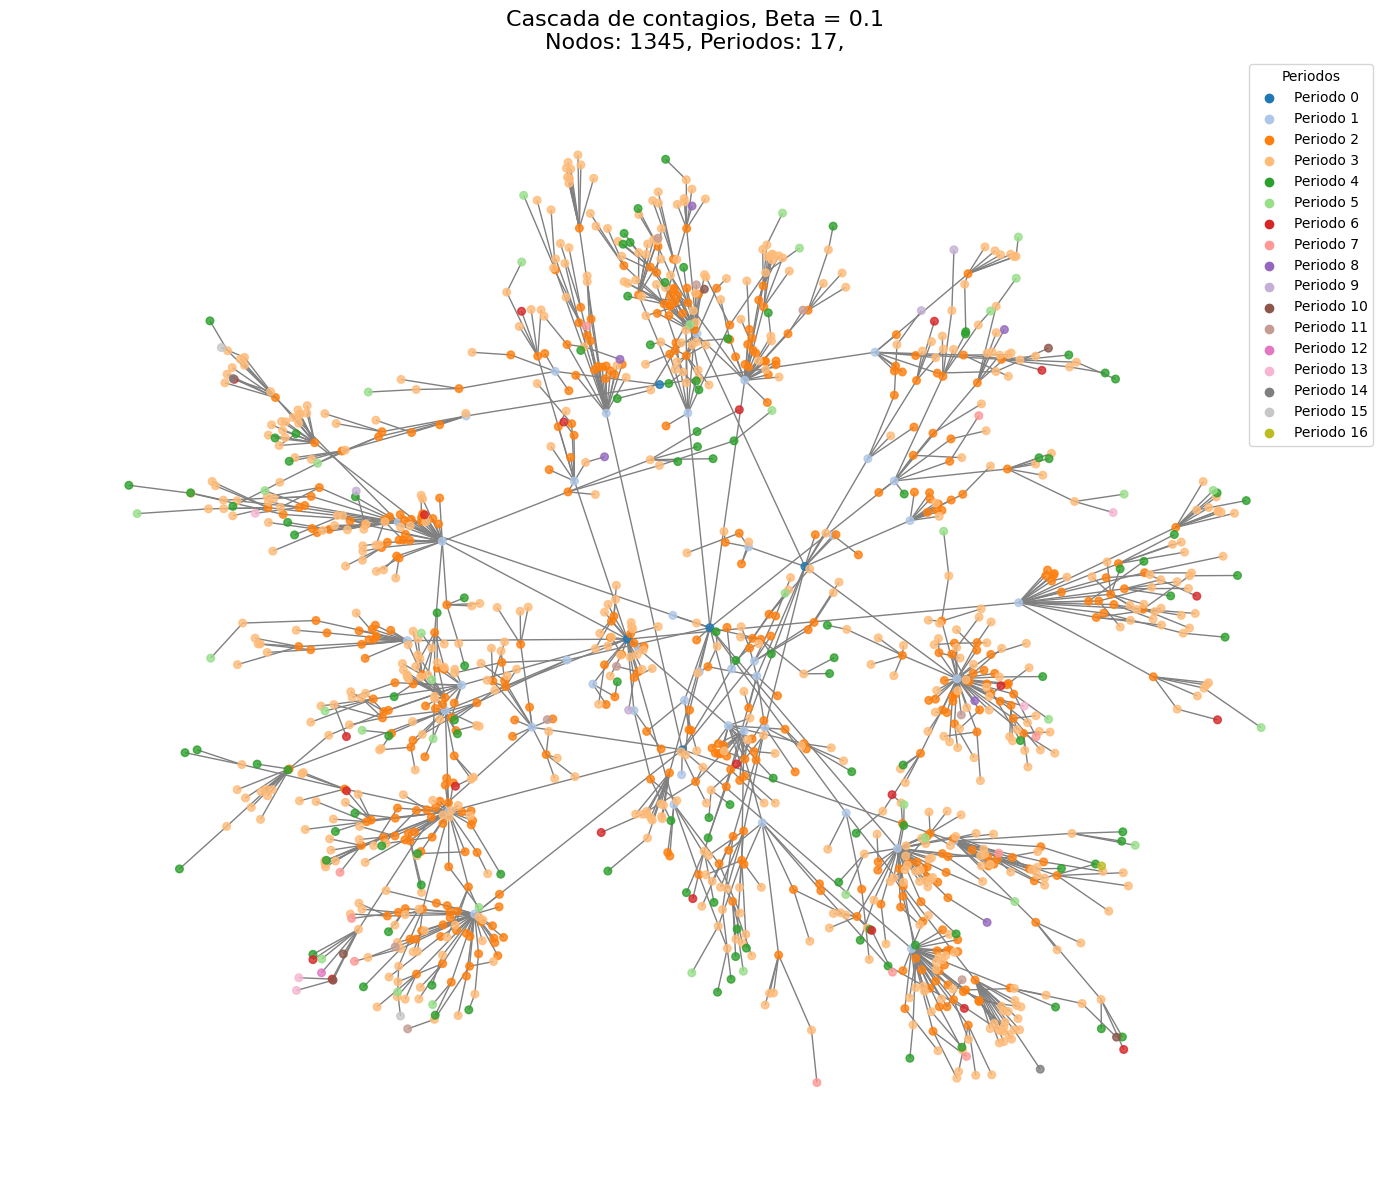

In [143]:
ut.contagion_cascade(g_infected = g_infected_simulations[0], beta=0.1)

#### 6.5.3 Beta = 0.3

In [144]:
log_simulations[log_simulations['beta'] == 0.3]

,t,susceptible,infected,recovered,new_infected,new_recovered,beta,gamma,n_starter_nodes,infected_percentage_acum
21,0,1383,5,0,5,0,0.3,0.1,5,0.36
22,1,1258,129,1,125,1,0.3,0.1,5,9.37
23,2,373,998,17,885,16,0.3,0.1,5,73.13
24,3,95,1183,110,278,93,0.3,0.1,5,93.16
25,4,57,1103,228,38,118,0.3,0.1,5,95.89
26,5,39,1010,339,18,111,0.3,0.1,5,97.19
27,6,35,936,417,4,78,0.3,0.1,5,97.48
28,7,32,838,518,3,101,0.3,0.1,5,97.69
29,8,25,761,602,7,84,0.3,0.1,5,98.20
30,9,22,695,671,3,69,0.3,0.1,5,98.41


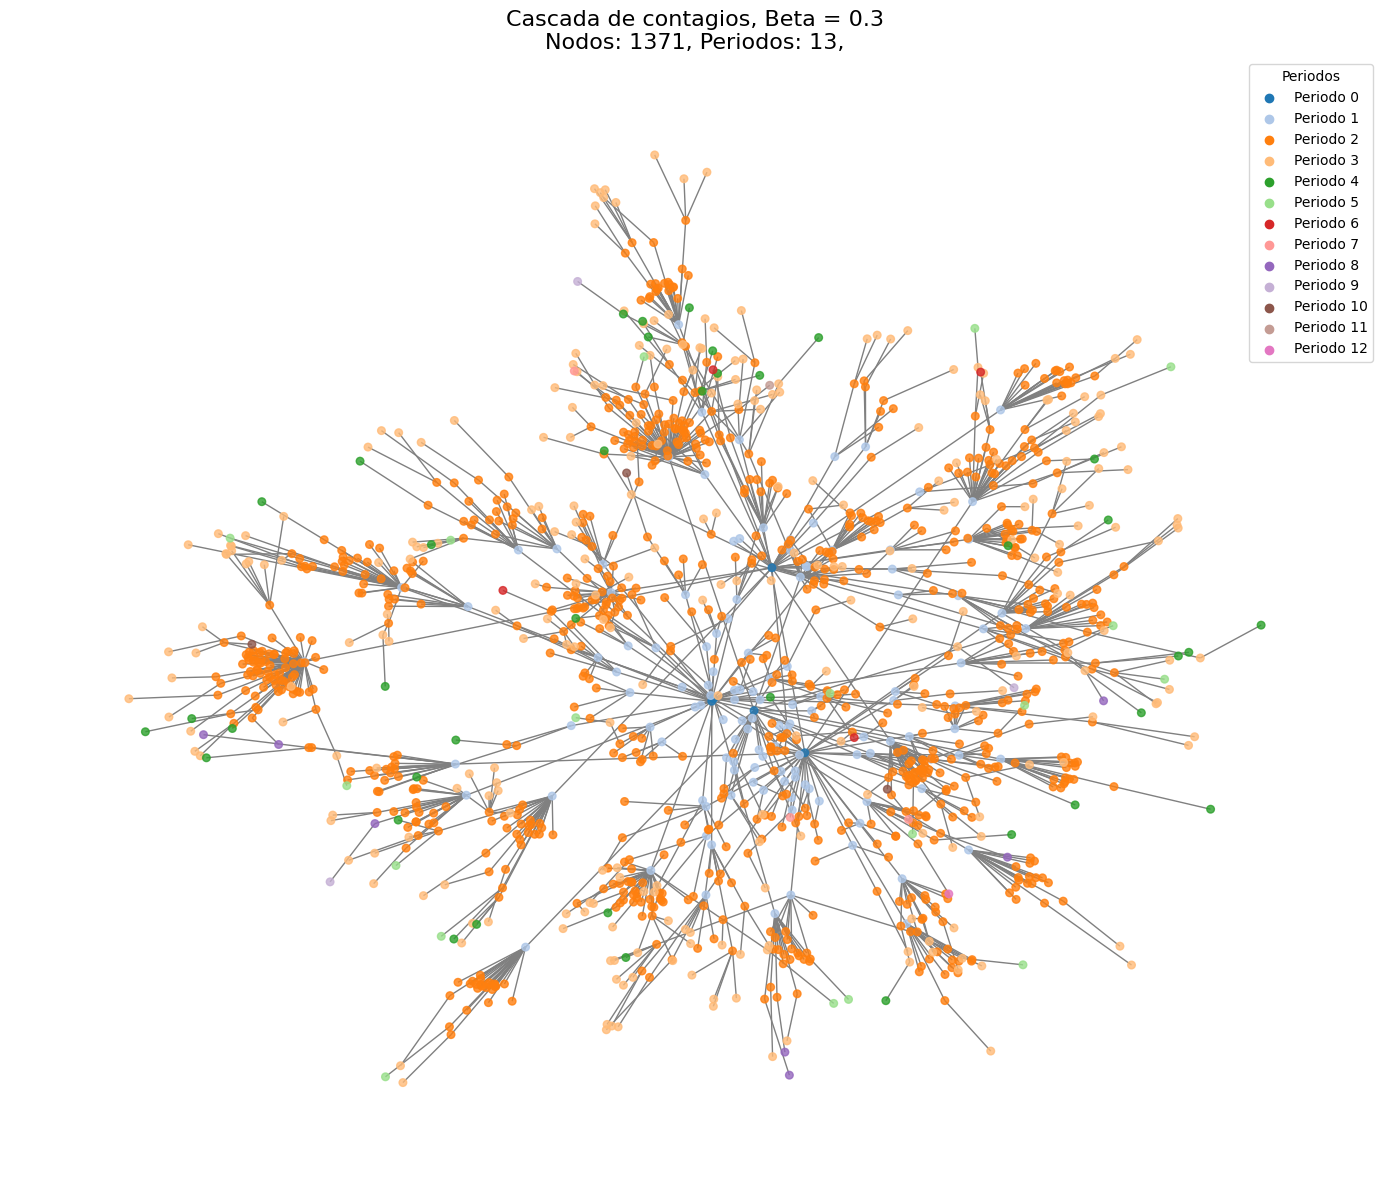

In [145]:
ut.contagion_cascade(g_infected = g_infected_simulations[1], beta=0.3)

#### 6.5.3 Beta = 0.5

In [146]:
log_simulations[log_simulations['beta'] == 0.5]

,t,susceptible,infected,recovered,new_infected,new_recovered,beta,gamma,n_starter_nodes,infected_percentage_acum
38,0,1383,5,0,5,0,0.5,0.1,5,0.36
39,1,1261,126,1,122,1,0.5,0.1,5,9.15
40,2,252,1122,14,1009,13,0.5,0.1,5,81.84
41,3,58,1195,135,194,121,0.5,0.1,5,95.82
42,4,28,1126,234,30,99,0.5,0.1,5,97.98
43,5,16,1025,347,12,113,0.5,0.1,5,98.85
44,6,10,921,457,6,110,0.5,0.1,5,99.28
45,7,8,836,544,2,87,0.5,0.1,5,99.42
46,8,6,740,642,2,98,0.5,0.1,5,99.57
47,9,5,669,714,1,72,0.5,0.1,5,99.64


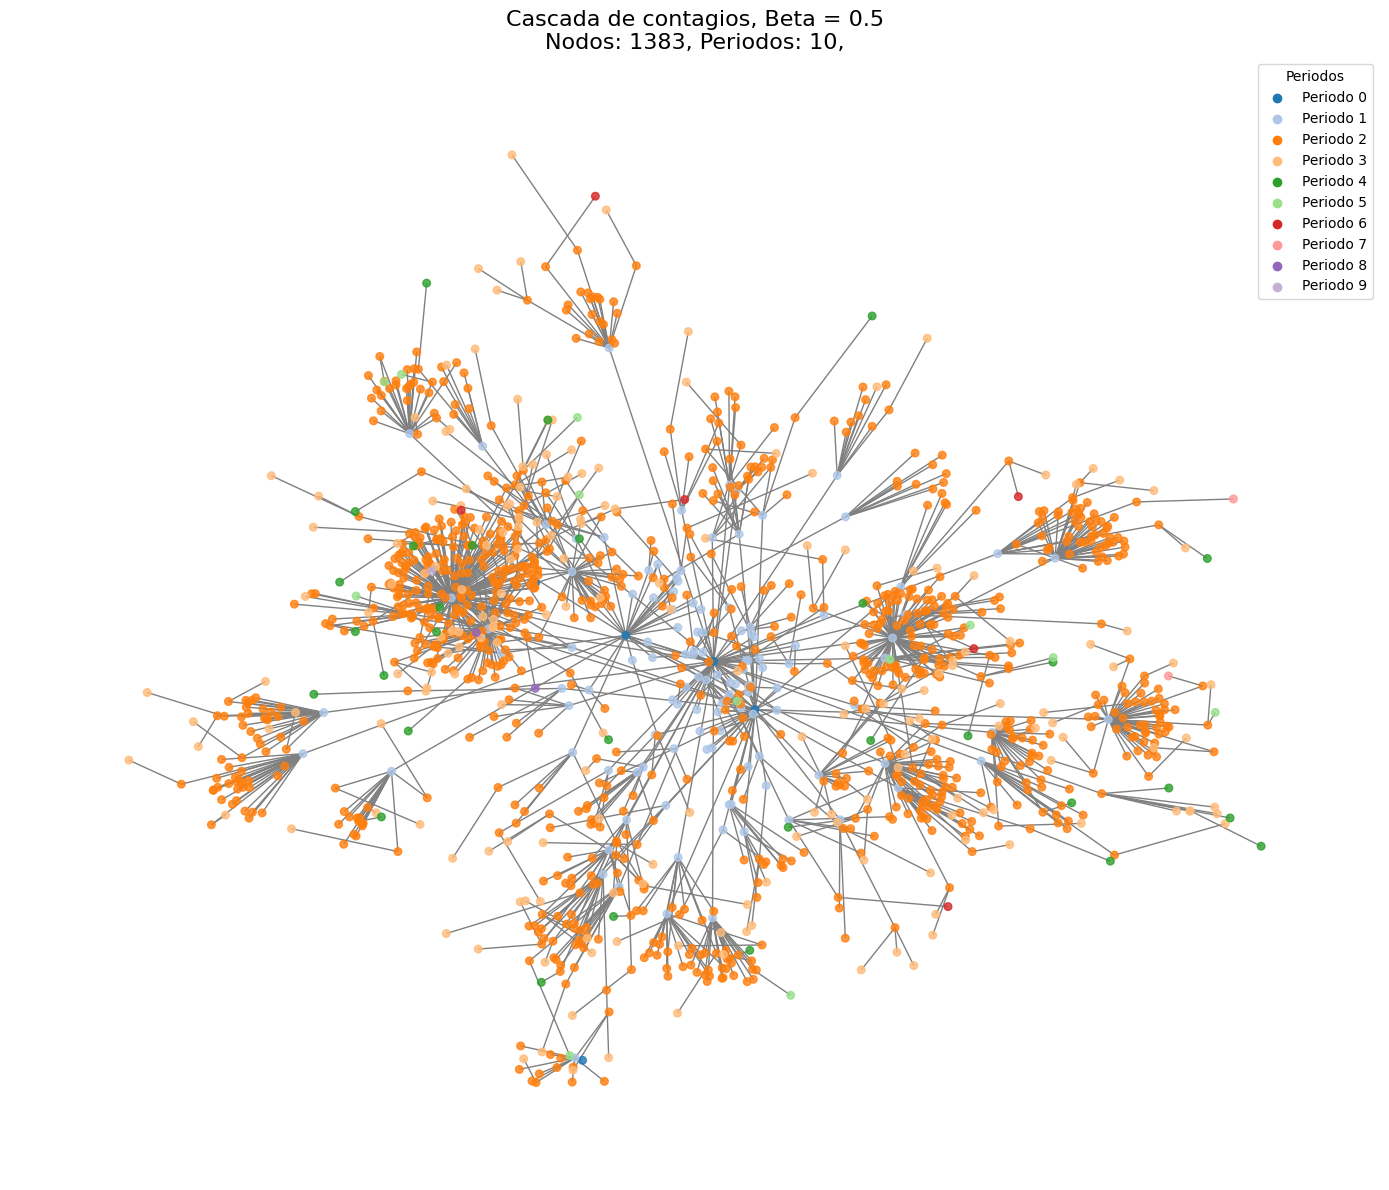

In [147]:
ut.contagion_cascade(g_infected = g_infected_simulations[2], beta=0.5)

#### 6.5.4 Beta = 0.7

In [148]:
log_simulations[log_simulations['beta'] == 0.7]

,t,susceptible,infected,recovered,new_infected,new_recovered,beta,gamma,n_starter_nodes,infected_percentage_acum
51,0,1383,5,0,5,0,0.7,0.1,5,0.36
52,1,1199,189,0,184,0,0.7,0.1,5,13.62
53,2,185,1190,13,1014,13,0.7,0.1,5,86.67
54,3,18,1246,124,167,111,0.7,0.1,5,98.70
55,4,4,1134,250,14,126,0.7,0.1,5,99.71
56,5,2,1008,378,2,128,0.7,0.1,5,99.86
57,6,1,906,481,1,103,0.7,0.1,5,99.93
58,7,1,806,581,0,100,0.7,0.1,5,99.93
59,8,1,721,666,0,85,0.7,0.1,5,99.93
60,9,1,650,737,0,71,0.7,0.1,5,99.93


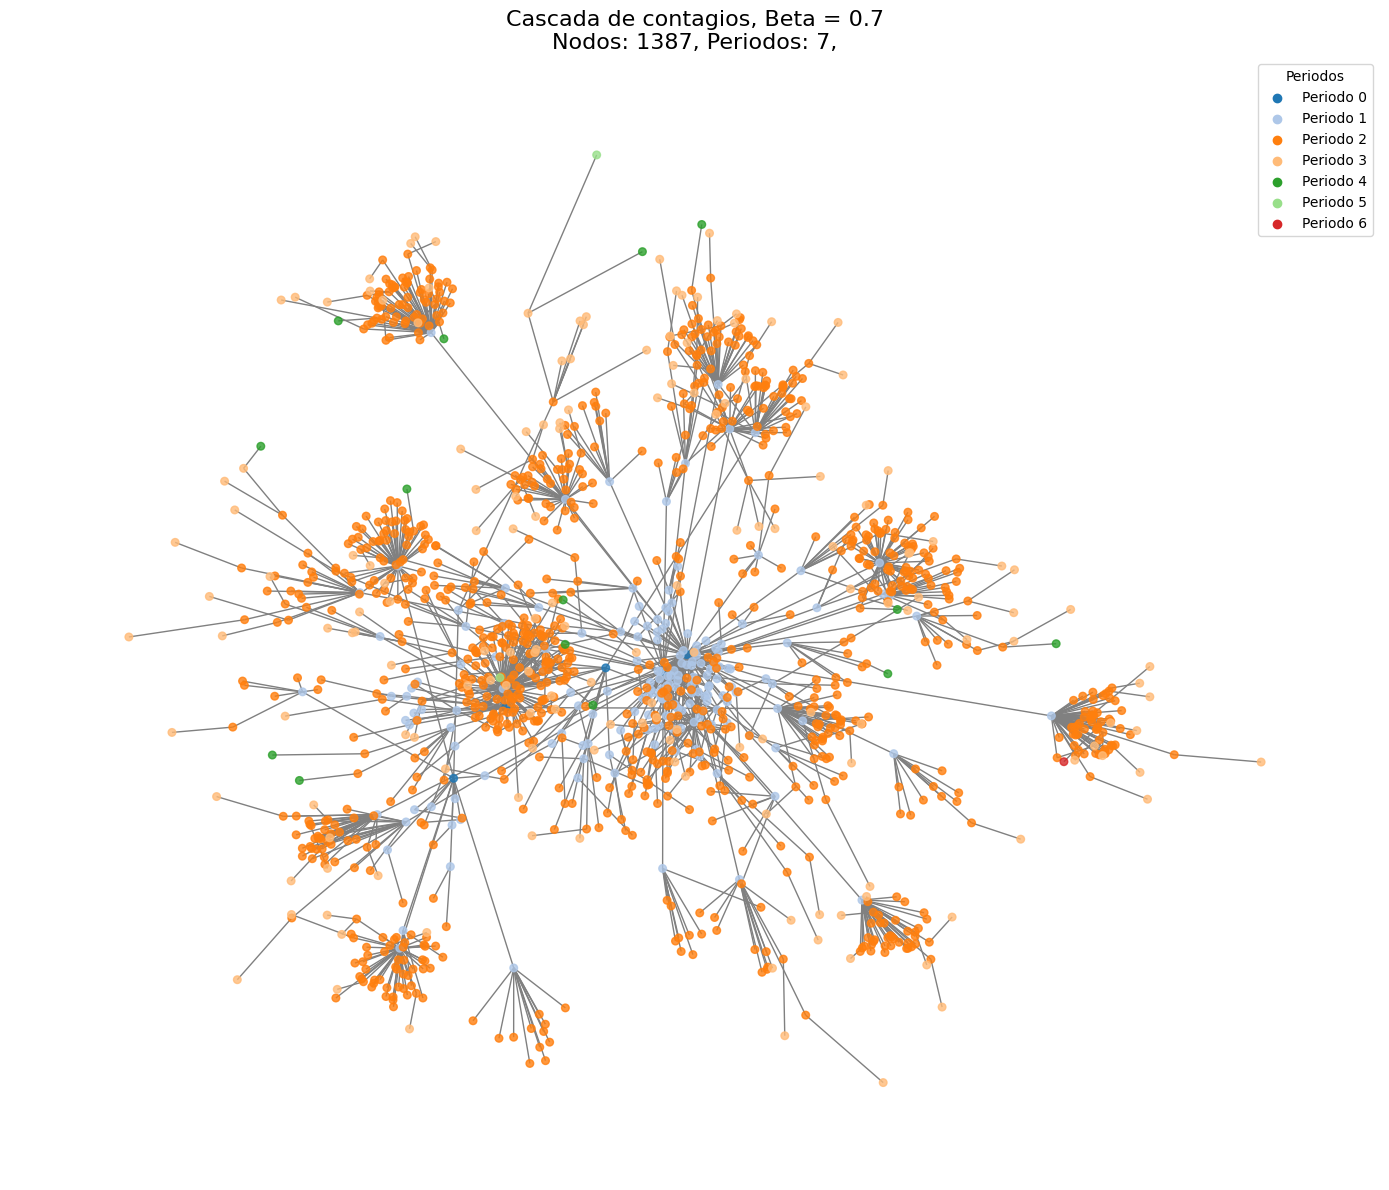

In [149]:
ut.contagion_cascade(g_infected = g_infected_simulations[3], beta=0.7)

## Conclusiones

    Se decide hacer el experimento con los siguientes parametros:
    - gamma = 0.1, como Probabilidad de recuperación.
    - n_starter_nodes = 5, como número de nodos iniciales infectados.
    - beta como probabilidad de contagio con los siguientes valores: [0.1, 0.3, 0.5, 0.7]

- Se observa que a mayor probabilidad de contagio (beta) la simulación termina en menos periodos, como es esperable. 
- Asi como también que dada la alta densidad del grafo, en todas las simulaciones el periodo 2 es el que tiene la mayor cantidad de nuevos infectados. Dada la velocidad con la que viaja la infección a traves de toda la red.